#Worksheet4
#Name:Alina Shrestha
#2408564
#L6CG8

In [3]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()  # choose AIML.zip

zip_file = list(uploaded.keys())[0]  # get uploaded file name
extract_path = "/content/AIML"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted to: {extract_path}")

Saving Copy of devnagari digit.zip to Copy of devnagari digit (1).zip
Dataset extracted to: /content/AIML


In [12]:
from google.colab import files

# This will open a file chooser to upload your zip
uploaded = files.upload()

Saving Copy of devnagari digit.zip to Copy of devnagari digit (2).zip


In [13]:
import zipfile
import os

# Get the uploaded file name
zip_path = list(uploaded.keys())[0]

# Where to extract
extract_path = "/content/AIML/DevanagariHandwrittenDigitDataset"
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/AIML/DevanagariHandwrittenDigitDataset


In [14]:
!ls /content/AIML/DevanagariHandwrittenDigitDataset


DevanagariHandwrittenDigitDataset  Test  Train


#Data preparation

In [16]:
import os

dataset_path = "/content/AIML/DevanagariHandwrittenDigitDataset"
print("Folders in dataset:")
print(os.listdir(dataset_path))

Folders in dataset:
['DevanagariHandwrittenDigitDataset', 'Train', 'Test']


#1. Import Libraries

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

#2.data preparation

In [43]:
train_path = "/content/AIML/DevanagariHandwrittenDigitDataset/Train"
test_path = "/content/AIML/DevanagariHandwrittenDigitDataset/Test"

IMG_SIZE = (28, 28)

def load_data(data_path):
    images = []
    labels = []

    for label_name in os.listdir(data_path):
        class_folder = os.path.join(data_path, label_name)

        if os.path.isdir(class_folder):
            label = int(label_name.split('_')[1])  # digit_0 → 0

            for img_file in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_file)

                img = Image.open(img_path).convert('L').resize(IMG_SIZE)
                img_array = np.array(img) / 255.0

                images.append(img_array)
                labels.append(label)

    images = np.array(images)
    labels = np.array(labels)

    images = images.reshape(images.shape[0], -1)  # flatten
    labels = to_categorical(labels, 10)

    return images, labels

X_train, y_train = load_data(train_path)
X_test, y_test = load_data(test_path)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (17000, 784) (17000, 10)
Test: (3000, 784) (3000, 10)


#3. Build FNC model

In [44]:
model = Sequential([
    Dense(64, activation='sigmoid', input_dim=784),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

#

#4.Compile Model

In [45]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#5.Train model

In [46]:
checkpoint = ModelCheckpoint(
    "/content/AIML/best_model.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2813 - loss: 2.0175
Epoch 1: val_loss improved from None to 7.97056, saving model to /content/AIML/best_model.h5



Epoch 1: finished saving model to /content/AIML/best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4798 - loss: 1.6501 - val_accuracy: 0.0000e+00 - val_loss: 7.9706
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7955 - loss: 0.6634
Epoch 2: val_loss did not improve from 7.97056
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8162 - loss: 0.5399 - val_accuracy: 0.0000e+00 - val_loss: 9.6171
Epoch 3/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8865 - loss: 0.3396
Epoch 3: val_loss did not improve from 7.97056
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9044 - loss: 0.3009 - val_accuracy: 0.0000e+00 - val_loss: 10.5823
Epoch 4/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9374 - loss: 0.2084
Epoch 4: val_loss did not improve from 7.97056
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9440 - loss: 0.1943 - val_accuracy: 0.0000e+00 - val_loss: 11.2281
Epoch 5/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

#6. Visualozation

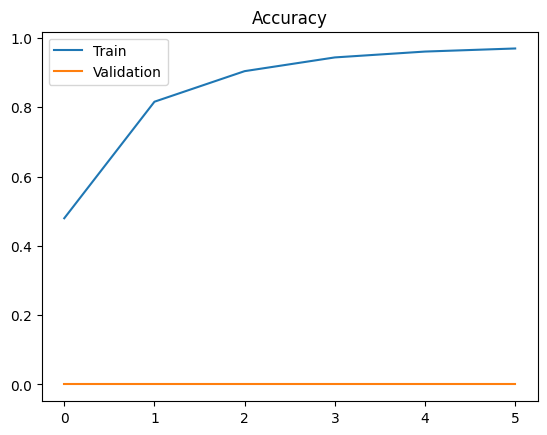

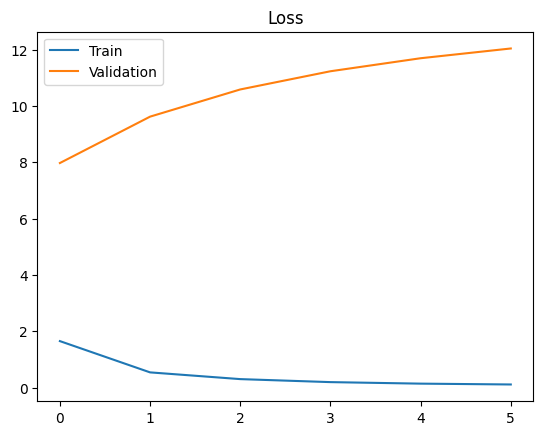

In [47]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

#Task 7: Evaluate the Model.

In [48]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6253 - loss: 2.2602
Test Accuracy: 0.625333309173584


#8. Sava and load the model

In [49]:
model.save("/content/AIML/devnagari_fcn_model.h5")

loaded_model = load_model("/content/AIML/devnagari_fcn_model.h5")

loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6253 - loss: 2.2602
Loaded Model Accuracy: 0.625333309173584


#Task 9. Prediction

In [50]:
y_pred_probs = loaded_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


#10.visualize the prediction

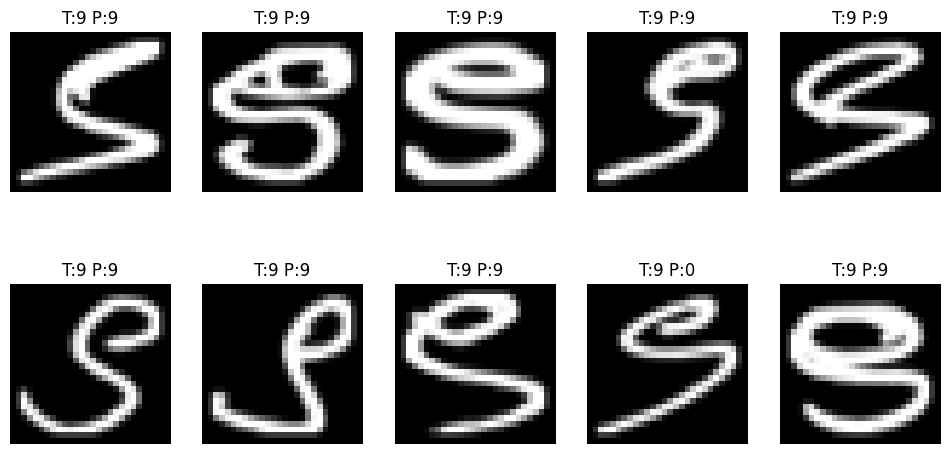

In [51]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"T:{y_true[i]} P:{y_pred[i]}")
    plt.axis('off')

plt.show()